<a href="https://colab.research.google.com/github/Vladzimir-40/Proj_1/blob/main/my_file5/dz_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install kagglehub

from google.colab import files
files.upload() # Загрузите файл kaggle.json

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"vladimir401011","key":"e6b9eec8a00a0a7c2c3e5fcbd033ab06"}'}

In [ ]:
import pandas as pd
import kagglehub
import os

class Data_loading:
    @staticmethod
    def load_from_kaggle(dataset_path, filename):
        """
        Загружает dataset из Kaggle используя kagglehub

        Args:
            dataset_path (str): путь к dataset на Kaggle
            filename (str): название файла для загрузки

        Returns:
            pd.DataFrame: загруженный датафрейм
        """
        download_path = kagglehub.dataset_download(dataset_path)
        file_path = os.path.join(download_path, filename)
        return pd.read_csv(file_path)

# Download latest version
path = kagglehub.dataset_download("sumedh1507/teen-phone-addiction")

print("Path to dataset files:", path)
print("\nЗагруженные файлы:")
for file in os.listdir(path):
    print(f"📁 {file}")

Using Colab cache for faster access to the 'teen-phone-addiction' dataset.
Path to dataset files: /kaggle/input/teen-phone-addiction

Загруженные файлы:
📁 teen_phone_addiction_dataset.csv


Плучаем датафрейм через статический метод, в который передем "путь" и "имя csv-файла"

In [ ]:
df = Data_loading.load_from_kaggle("sumedh1507/teen-phone-addiction", "teen_phone_addiction_dataset.csv")

Using Colab cache for faster access to the 'teen-phone-addiction' dataset.


In [ ]:
# Просматриваем первые несколько строк датасета
print(df.head())
print(df.describe())

# Получаем общую информацию о датасете
print(df.info())

   ID               Name  Age  Gender          Location School_Grade  \
0   1    Shannon Francis   13  Female        Hansonfort          9th   
1   2    Scott Rodriguez   17  Female      Theodorefort          7th   
2   3        Adrian Knox   13   Other       Lindseystad         11th   
3   4  Brittany Hamilton   18  Female      West Anthony         12th   
4   5       Steven Smith   14   Other  Port Lindsaystad          9th   

   Daily_Usage_Hours  Sleep_Hours  Academic_Performance  Social_Interactions  \
0                4.0          6.1                    78                    5   
1                5.5          6.5                    70                    5   
2                5.8          5.5                    93                    8   
3                3.1          3.9                    78                    8   
4                2.5          6.7                    56                    4   

   ...  Screen_Time_Before_Bed  Phone_Checks_Per_Day  Apps_Used_Daily  \
0  ...       

1 Name -> Имя

2 Age -> Возраст

3 Gender -> Пол

4 Location -> Местоположение

5 School_Grade -> Класс_обучения (или Школьный_класс)

6 Daily_Usage_Hours -> Ежедневное_использование_часов

7 Sleep_Hours -> Часы_сна

8 Academic_Performance -> Успеваемость (или Академическая_успеваемость)

9 Social_Interactions -> Социальные_взаимодействия (или Общение)

10 Exercise_Hours -> Часы_тренировок (или Часы_физических_упражнений)

11 Anxiety_Level -> Уровень_тревожности

12 Depression_Level -> Уровень_депрессии

13 Self_Esteem -> Самооценка

14 Parental_Control -> Родительский_контроль

15 Screen_Time_Before_Bed -> Время_у_экрана_перед_сном

16 Phone_Checks_Per_Day -> Проверки_телефона_в_день

17 Apps_Used_Daily -> Приложений_используемых_ежедневно

18 Time_on_Social_Media -> Время_в_соцсетях

19 Time_on_Gaming -> Время_за_играми

20 Time_on_Education -> Время_на_образование (или Учебное_время)

21 Phone_Usage_Purpose -> Цель_использования_телефона
22 Family_Communication -> Общение_с_семьей

23 Weekend_Usage_Hours -> Часы_использования_в_выходные

24 Addiction_Level -> Уровень_зависимости (от 0.0 до 10.0)

Датасет содержит информацию о том, как много времени дети проводят в телефонах, а итоговыми показателями могут служить и «Уровень тревожности», и "Уровень депрессии", и "Успеваемость", и "Социальное взаимодействие", но проверять (брать за таргет) мы будем "Уровень зависимости" у детей от телефонов в диапазоне от 1(Независимы) до 10(Зависимы).

Таким образом решаться будет обычная регрессионная задачка. Обучим модели: "Ridge Regression", "Bayesian Ridge", "Decision Tree", "Gradient Boosting", "LGBM Regressor"; и посмотрим, кто лучше определит "Уровень зависимости" у детей от телефонов, если все остальные показатели подать в виде параметров.


НАЧИНАЕМ ОЦЕНКУ МОДЕЛЕЙ...

Ridge Regression
MSE:  0.6659
RMSE: 0.8160
MAE:  0.6525
R²:   0.7357


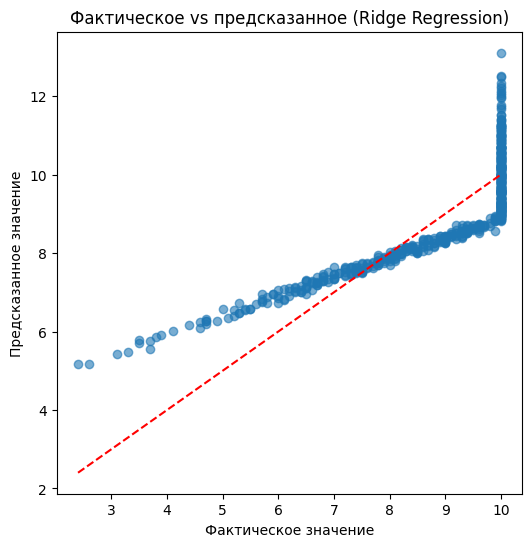


Bayesian Ridge
MSE:  0.6661
RMSE: 0.8162
MAE:  0.6523
R²:   0.7356


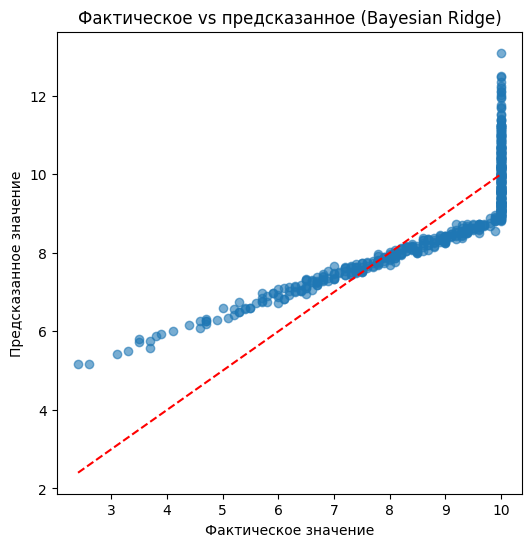


Decision Tree
MSE:  1.1297
RMSE: 1.0629
MAE:  0.7068
R²:   0.5516


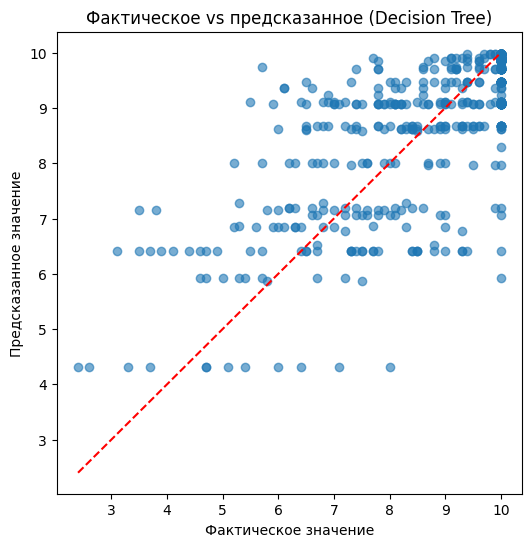


Gradient Boosting
MSE:  0.2360
RMSE: 0.4858
MAE:  0.3785
R²:   0.9063


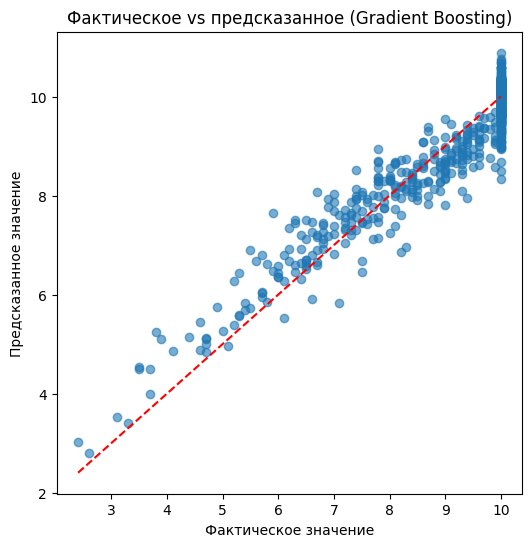


LGBM Regressor
MSE:  0.1449
RMSE: 0.3806
MAE:  0.2640
R²:   0.9425


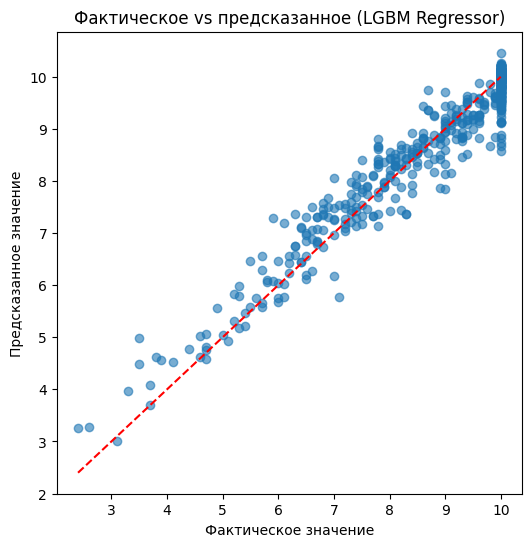

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder

# Импортируем выбранные модели
from sklearn.linear_model import Ridge  # Гребневая регрессия
from sklearn.linear_model import BayesianRidge  # Байесовская регрессия
from sklearn.tree import DecisionTreeRegressor  # Регрессор дерева решений
from sklearn.ensemble import GradientBoostingRegressor  # Регрессор Gradient Boosting
from lightgbm import LGBMRegressor  # Регрессор LGBM

# Функция обучения, предсказания и последующего анализа моделей
def regress_analys(X_tr, y_tr, X_tst, y_tst, model, model_name):

    # 1. Обучаем модель
    model.fit(X_tr, y_tr)

    # 2. Получаем предсказания моделей
    y_pr = model.predict(X_tst)

    # 3. Вычисляем метрики качества:
    mean_sq_err = mean_squared_error(y_tst, y_pr)
    root_mse = np.sqrt(mean_sq_err)
    mean_abs_err = mean_absolute_error(y_tst, y_pr)
    r2_coeff_dtrm = r2_score(y_tst, y_pr)

    # 4. Выводим результаты
    print(f"\n{model_name}")
    print("=" * 40)
    print(f"MSE:  {mean_sq_err:.4f}")
    print(f"RMSE: {root_mse:.4f}")
    print(f"MAE:  {mean_abs_err:.4f}")
    print(f"R²:   {r2_coeff_dtrm:.4f}")

    # 5. Возвращаем предсказания
    return y_pr

# Функция визуализации
def view(y_tst, y_pr, model_name):
    plt.figure(figsize=(6, 6))
    plt.scatter(y_tst, y_pr, alpha=0.6)
    plt.plot([y_tst.min(), y_tst.max()], [y_tst.min(), y_tst.max()],
             color="red", linestyle="--")
    plt.xlabel("Фактическое значение")
    plt.ylabel("Предсказанное значение")
    plt.title(f"Фактическое vs предсказанное ({model_name})")
    plt.show()

# ПРЕДВАРИТЕЛЬНАЯ ОБРАБОТКА ДАННЫХ
# Удаляем колонку с именами (Имена детей не несут никако полезной информации для модели)
if 'Name' in df.columns:
    df = df.drop(columns=['Name'])

# Кодируем категориальные переменные
categorical_columns = df.select_dtypes(include=['object']).columns
label_encoders = {}
for col in categorical_columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

# Подготовка данных
X = df.drop(columns=['Addiction_Level'])  # Признаки
y = df['Addiction_Level']  # Целевая переменная

# Разделяем данные на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Создаем и тестируем модели
models = {
    "Ridge Regression": Ridge(alpha=1.0),
    "Bayesian Ridge": BayesianRidge(),
    "Decision Tree": DecisionTreeRegressor(max_depth=5, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
    "LGBM Regressor": LGBMRegressor(n_estimators=100, random_state=42, verbose=0)
}

print("НАЧИНАЕМ ОЦЕНКУ МОДЕЛЕЙ...")
print("=" * 60)

# Оцениваем каждую модель
for name, model in models.items():
    # 1. Вызываем функцию обучения и анализа: получаем предсказания, выводим метрики
    y_pred = regress_analys(X_train, y_train, X_test, y_test, model, name)

    # 2. Визуализируем результат
    view(y_test, y_pred, name)



Модель "LGBM Regressor" опеределанно лидер

MSE:  0.1449

RMSE: 0.3806

MAE:  0.2640

R²:   0.9425

На почетном втором месте модель "Gradient Boosting"

MSE:  0.2360

RMSE: 0.4858

MAE:  0.3785

R²:   0.9063

**Работа с синтетикой**

НАЧИНАЕМ ОЦЕНКУ МОДЕЛЕЙ НА УСЛОЖНЕННЫХ ДАННЫХ...

Ridge Regression
MSE:  408.4935
RMSE: 20.2112
MAE:  16.2708
R²:   0.9748


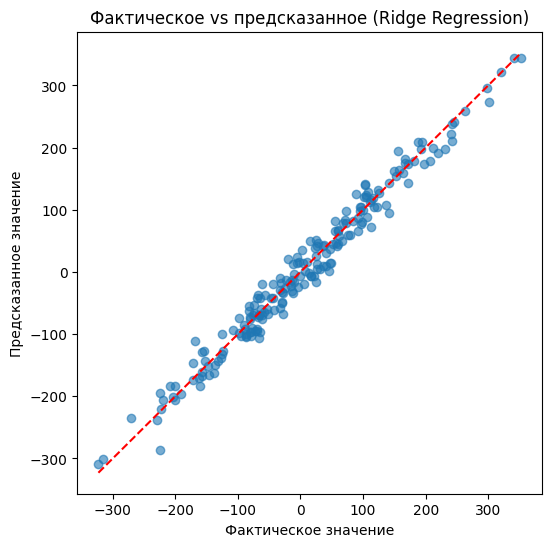


Bayesian Ridge
MSE:  408.5765
RMSE: 20.2133
MAE:  16.2842
R²:   0.9748


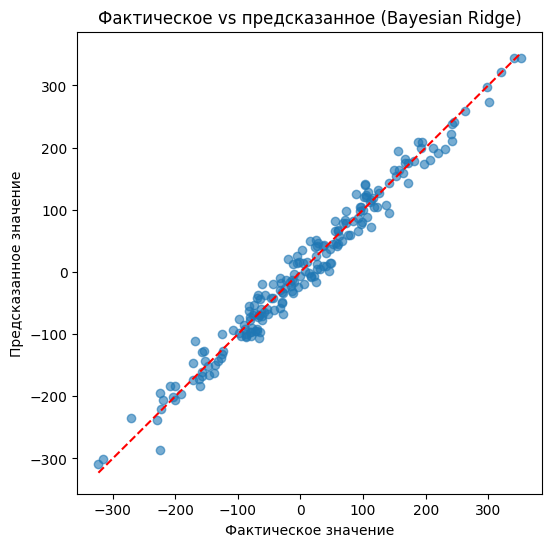


Decision Tree
MSE:  1661.1363
RMSE: 40.7570
MAE:  31.9230
R²:   0.8976


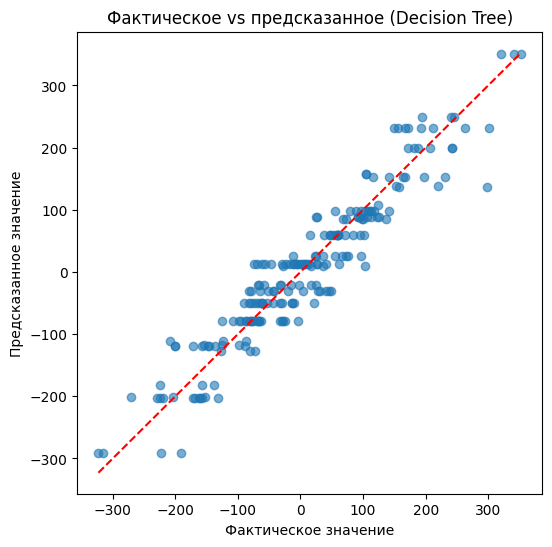


Gradient Boosting
MSE:  546.3474
RMSE: 23.3741
MAE:  17.9510
R²:   0.9663


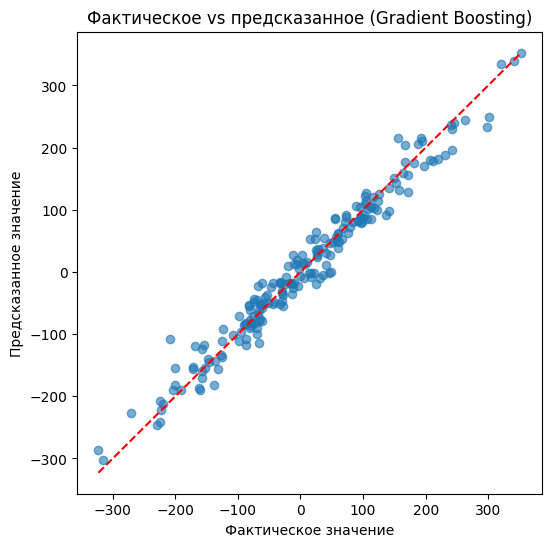


LGBM Regressor
MSE:  671.7345
RMSE: 25.9178
MAE:  19.1242
R²:   0.9586


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


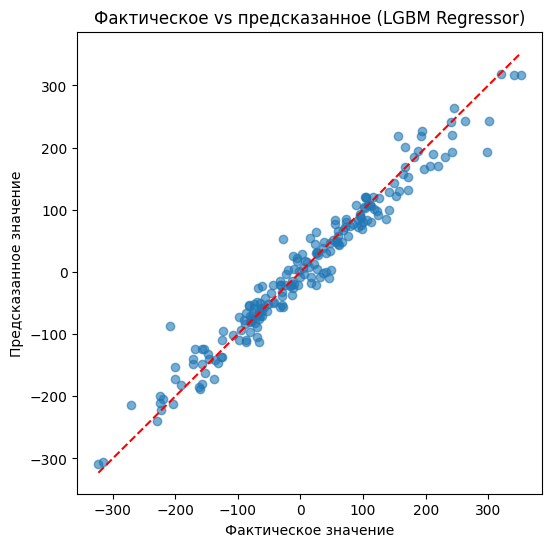

In [ ]:
from sklearn.datasets import make_regression

# Создаем сложные синтетические данные
X, y = make_regression(
    n_samples=1000,
    n_features=3,           # 3 признака
    noise=20,
    random_state=42,
    n_informative=2         # 2 информативных признака
)

# Разделяем данные на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Обновляем модели
models = {
    "Ridge Regression": Ridge(alpha=1.0),
    "Bayesian Ridge": BayesianRidge(),
    "Decision Tree": DecisionTreeRegressor(max_depth=5, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
    "LGBM Regressor": LGBMRegressor(
        n_estimators=50,
        max_depth=3,
        learning_rate=0.1,
        random_state=42,
        verbose=-1         # -1 вариант изменить с 0, чтобы не ругался
    )
}

print("НАЧИНАЕМ ОЦЕНКУ МОДЕЛЕЙ НА УСЛОЖНЕННЫХ ДАННЫХ...")
print("=" * 60)

# Оцениваем каждую модель
for name, model in models.items():
    # 1. Вызываем функцию обучения и анализа
    y_pred = regress_analys(X_train, y_train, X_test, y_test, model, name)

    # 2. Визуализируем результат
    view(y_test, y_pred, name)

Первое мето поделили модели "Ridge Regression" и "Bayesian Ridge" с очень близкими значиями R^2: 0.9748 (то есть даные очень хорошо объеснены).

Непонятные, но очень большие значения остальных метрик MSE, RMSE, MAE вероятно указывают на то, что данные синтетические